# 📊 Análise Exploratória - Dados Brutos de Crimes Violentos (2024)

Este notebook tem como objetivo explorar os dados brutos de crimes violentos ocorridos em Minas Gerais no ano de 2024, **sem nenhum pré-processamento**. A análise busca entender a estrutura, qualidade e distribuição inicial dos dados.

Fonte: Arquivos CSV fornecidos pelo projeto original da transparência pública do estado de Minas Gerais.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
plt.style.use('seaborn-v0_8-muted')
sns.set_palette('Set2')

# Caminho do arquivo bruto
caminho_arquivo = '../data/raw/crimes_violentos_2024.csv'

# Leitura dos dados
df = pd.read_csv(caminho_arquivo, sep=';', encoding='utf-8')


## 👁️ Visualização inicial dos dados

Verificamos as primeiras linhas do arquivo para entender sua estrutura e os tipos de colunas presentes.


In [4]:
display(df.head())

,registros,natureza,municipio,cod_municipio,mes,ano,risp,rmbh
0,0,Estupro Consumado,ABADIA DOS DOURADOS,310010,1,2024,10,NÃO
1,0,Estupro Consumado,ABAETE,310020,1,2024,7,NÃO
2,0,Estupro Consumado,ABRE-CAMPO,310030,1,2024,12,NÃO
3,0,Estupro Consumado,ACAIACA,310040,1,2024,12,NÃO
4,1,Estupro Consumado,ACUCENA,310050,1,2024,12,NÃO


## ℹ️ Informações Gerais

Aqui verificamos a estrutura do DataFrame, os tipos de dados e a memória utilizada.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133068 entries, 0 to 133067
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   registros      133068 non-null  int64 
 1   natureza       133068 non-null  object
 2   municipio      133068 non-null  object
 3   cod_municipio  133068 non-null  int64 
 4   mes            133068 non-null  int64 
 5   ano            133068 non-null  int64 
 6   risp           133068 non-null  int64 
 7   rmbh           133068 non-null  object
dtypes: int64(5), object(3)
memory usage: 8.1+ MB


## 📈 Estatísticas Descritivas

Visualizamos estatísticas básicas para as colunas numéricas e categóricas.


In [6]:
display(df.describe())
display(df.describe(include='object'))

,registros,cod_municipio,mes,ano,risp
count,133068.000000,133068.000000,133068.000000,133068.0,133068.000000
mean,0.242049,313697.720985,6.500000,2024.0,10.875733
std,5.811895,2070.893942,3.452066,0.0,4.721179
min,0.000000,310010.000000,1.000000,2024.0,1.000000
25%,0.000000,311950.000000,3.750000,2024.0,7.000000
50%,0.000000,313730.000000,6.500000,2024.0,12.000000
75%,0.000000,315490.000000,9.250000,2024.0,15.000000
max,668.000000,317220.000000,12.000000,2024.0,19.000000


,natureza,municipio,rmbh
count,133068,133068,133068
unique,13,853,2
top,Estupro Consumado,WENCESLAU BRAZ,NÃO
freq,10236,156,127920


## ❓ Verificação de Valores Ausentes


In [7]:
df.isnull().sum()

registros        0
natureza         0
municipio        0
cod_municipio    0
mes              0
ano              0
risp             0
rmbh             0
dtype: int64

## 📆 Distribuição dos Registros por Mês

Observamos  a **quantidade real de crimes** registrados em cada mês (soma da coluna `registros`).



Total de registros (crimes) por mês:
mes
1     2633
2     2375
3     2482
4     2602
5     2627
6     2879
7     2982
8     2810
9     2781
10    2828
11    2657
12    2553
Name: registros, dtype: int64


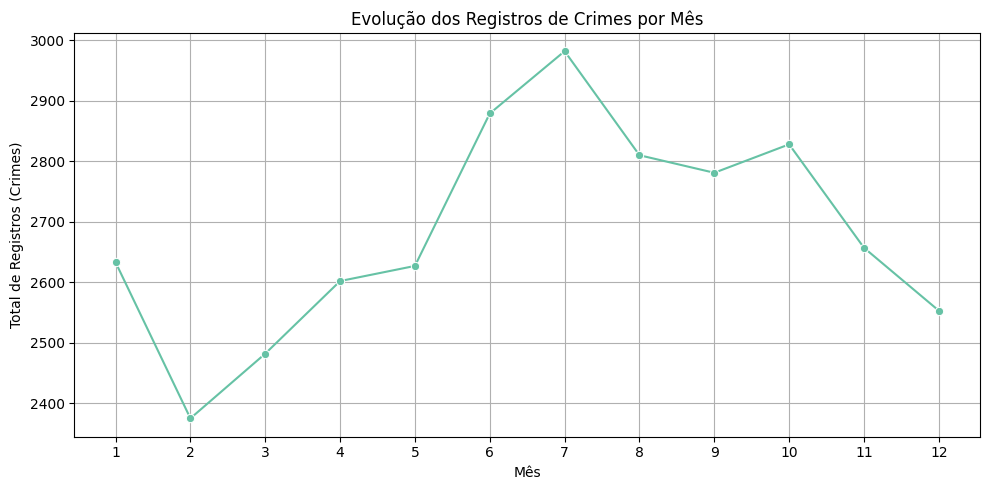

In [8]:
registros_por_mes = df.groupby('mes')['registros'].sum().sort_index()
print("\nTotal de registros (crimes) por mês:")
print(registros_por_mes)

# Gráfico
plt.figure(figsize=(10,5))
sns.lineplot(x=registros_por_mes.index, y=registros_por_mes.values, marker='o')
plt.title('Evolução dos Registros de Crimes por Mês')
plt.xlabel('Mês')
plt.ylabel('Total de Registros (Crimes)')
plt.xticks(range(1,13))
plt.grid(True)
plt.tight_layout()
plt.show()


## 🧪 Distribuição por Natureza do Crime

A seguir, analisamos as naturezas dos crimes mais recorrentes em termos de total de registros (coluna `registros`).


natureza
Roubo Consumado                          18595
Estupro de Vulnerável Consumado           3600
Homicídio Tentado                         3009
Homicídio Consumado (Registros)           2635
Estupro Consumado                         1309
Roubo Tentado                             1171
Extorsão Consumado                        1019
Sequestro e Cárcere Privado Consumado      297
Estupro Tentado                            213
Extorsão Tentado                           190
Name: registros, dtype: int64

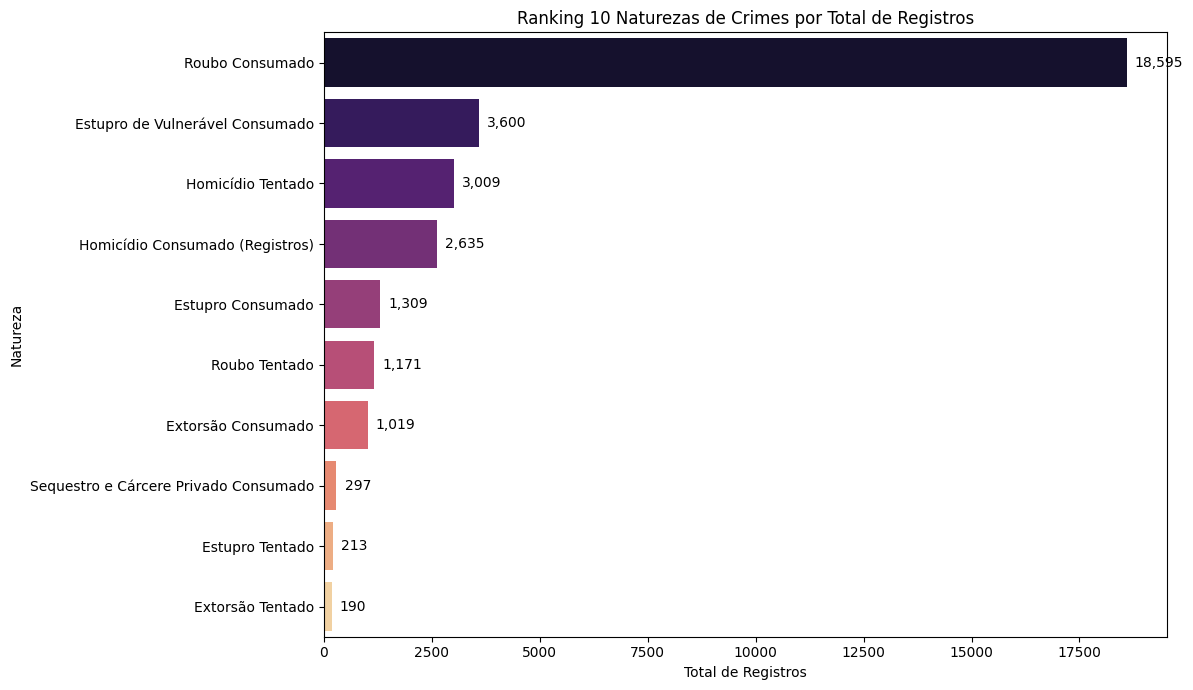

In [10]:
top_naturezas = df.groupby('natureza')['registros'].sum().sort_values(ascending=False).head(10)
display(top_naturezas)

plt.figure(figsize=(12,7))
ax = sns.barplot(
    x=top_naturezas.values,
    y=top_naturezas.index,
    hue=top_naturezas.index,   # Adiciona hue igual ao eixo y
    palette='magma',
    legend=False               # Remove legenda redundante
)
for i, v in enumerate(top_naturezas.values):
    ax.text(v + max(top_naturezas.values)*0.01, i, f'{v:,}', color='black', va='center')
plt.title('Ranking 10 Naturezas de Crimes por Total de Registros')
plt.xlabel('Total de Registros')
plt.ylabel('Natureza')
plt.tight_layout()
plt.show()


## 🏙️ Ranking dos 10 Municípios com Mais Crimes

Analisamos os municípios com maior número total de registros de crimes.


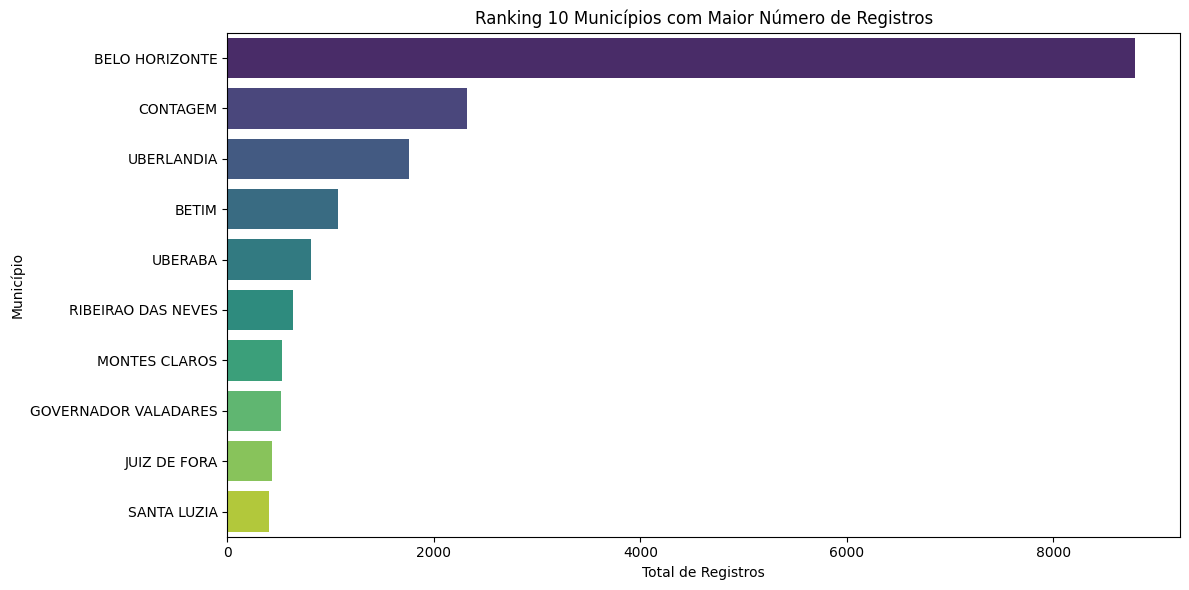

In [11]:
top_municipios = df.groupby('municipio')['registros'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(
    x=top_municipios.values,
    y=top_municipios.index,
    hue=top_municipios.index,    # Adiciona hue igual ao eixo y
    palette='viridis',
    legend=False                 # Remove legenda redundante
)
plt.title('Ranking 10 Municípios com Maior Número de Registros')
plt.xlabel('Total de Registros')
plt.ylabel('Município')
plt.tight_layout()
plt.show()


## 📊 Evolução Mensal dos Top 5 Crimes

Visualizamos agora como se comportaram, ao longo dos meses, os 5 crimes mais frequentes em número de registros.


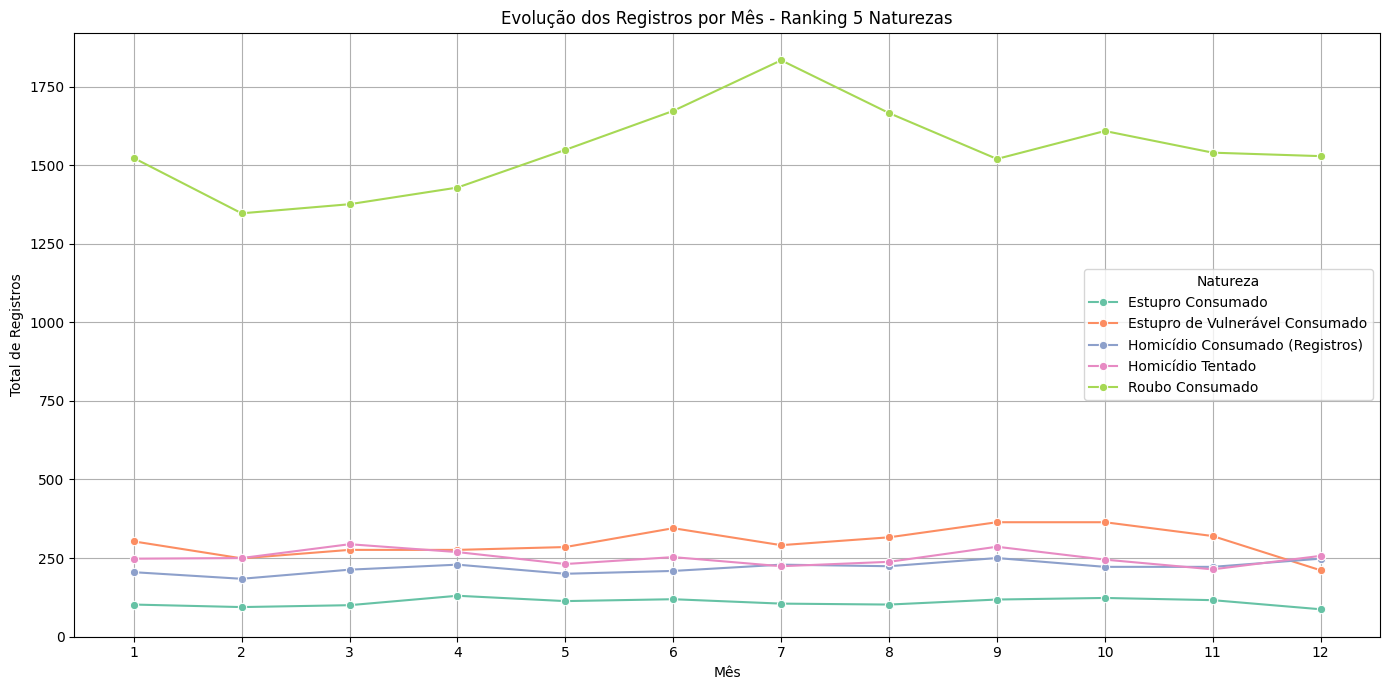

In [12]:
top5_naturezas = top_naturezas.head(5).index.tolist()
df_top5 = df[df['natureza'].isin(top5_naturezas)]
registros_top5 = df_top5.groupby(['mes', 'natureza'])['registros'].sum().reset_index()

plt.figure(figsize=(14,7))
sns.lineplot(data=registros_top5, x='mes', y='registros', hue='natureza', marker='o')
plt.title('Evolução dos Registros por Mês - Ranking 5 Naturezas')
plt.xlabel('Mês')
plt.ylabel('Total de Registros')
plt.xticks(range(1,13))
plt.grid(True)
plt.legend(title='Natureza')
plt.tight_layout()
plt.show()


## 🚓 Registros por Região Integrada de Segurança Pública (RISP)
As RISPs (Regiões Integradas de Segurança Pública) são divisões territoriais usadas pelas forças de segurança para organizar e distribuir melhor os recursos. Aqui analisamos a distribuição de crimes por RISP.


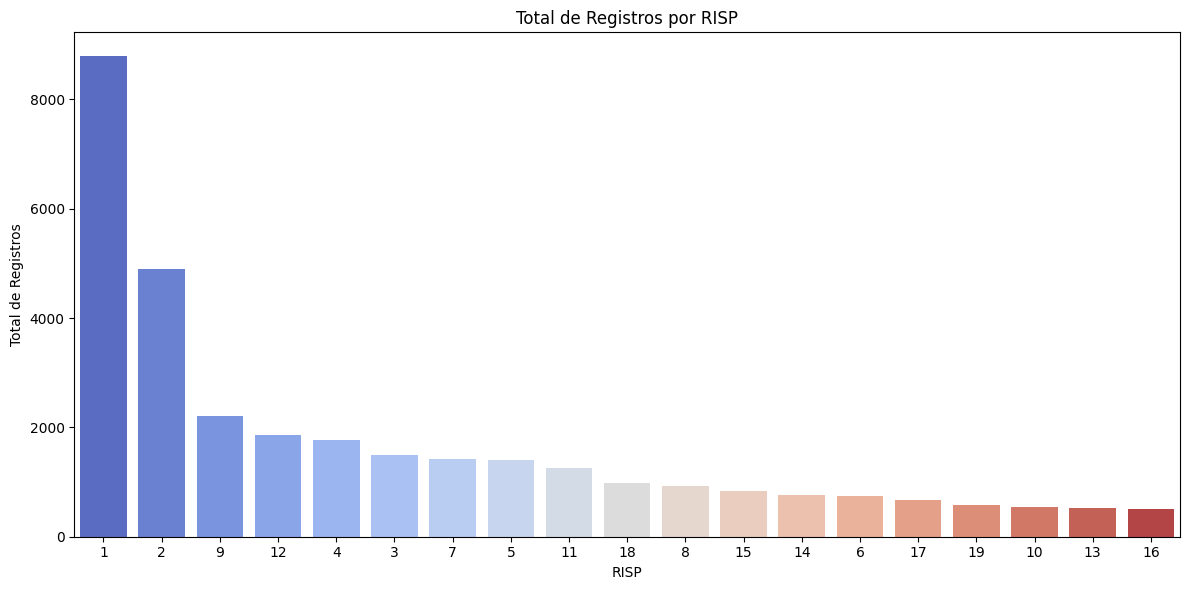

In [13]:
registros_por_risp = df.groupby('risp')['registros'].sum().sort_values(ascending=False)
registros_por_risp

plt.figure(figsize=(12,6))
sns.barplot(
    x=registros_por_risp.index.astype(str),
    y=registros_por_risp.values,
    hue=registros_por_risp.index.astype(str),
    palette='coolwarm',
    legend=False  
)
plt.title('Total de Registros por RISP')
plt.xlabel('RISP')
plt.ylabel('Total de Registros')
plt.tight_layout()
plt.show()

## ✅ Conclusões Iniciais

- Os dados brutos já possuem estrutura bem definida, com colunas consistentes e sem valores nulos.
- Os crimes se distribuem relativamente de forma homogênea entre os meses, com algumas variações em registros.
- Algumas naturezas de crime concentram a maior parte dos registros (como homicídio e estupro).
- Municípios com maiores populações naturalmente concentram mais ocorrências.
- As RISPs com maior número de ocorrências podem indicar áreas prioritárias para ações de segurança pública.


A necessidade de tratamento e junção será realizada no próximo notebook.
